# Atividade 7 — Análise de Variância: Métodos de Ensino de Matemática

**Enunciado:** *"Uma secretaria de educação pretende avaliar quatro métodos de ensino de matemática, identificados por M1, M2, M3 e M4.*

*Para realizar o estudo, foram selecionadas aleatoriamente seis escolas dentre todas as escolas da rede pública. Em cada escola, os quatro métodos foram aplicados em turmas distintas e, ao final do semestre letivo, foi registrada a nota média obtida pelos alunos em uma prova padronizada de matemática.*

*O objetivo principal da secretaria é recomendar o método de ensino mais eficiente para ser adotado em toda a rede pública. Além disso, a secretaria deseja quantificar a variabilidade existente entre as escolas."*

Realize uma análise completa dos dados, incluindo: (1) identificação do delineamento experimental; (2) análise exploratória; (3) ajuste do modelo adequado; (4) verificação dos pressupostos; (5) teste de hipóteses para efeito de métodos e para efeito de escolas; (6) comparações múltiplas entre os métodos; (7) estimação da variância entre escolas; (8) conclusão prática para a secretaria.

---

## Etapa 0: Contextualizando

Temos **4 métodos de ensino** (M1, M2, M3, M4) aplicados em **6 escolas** diferentes, com uma nota média por combinação escola–método. O total de observações é $4 \times 6 = 24$.

A estrutura do problema tem duas camadas:

* $\text{Método}$: fator de tratamento **fixo** — a secretaria quer recomendar especificamente um dos quatro métodos.
* $\text{Escola}$: fator de bloco **aleatório** — as seis escolas são apenas uma amostra da população de escolas da rede pública; a secretaria quer *quantificar* a variabilidade entre escolas, não comparar escolas específicas.

Toda a análise será feita em **R**.

---

## Etapa 1: Identificação do Delineamento Experimental

#### 1.1 Qual é o delineamento?

O delineamento utilizado é o **Delineamento em Blocos Casualizados com Bloco Aleatório** (também chamado de *Two-way mixed model* ou Blocos Aleatórios).

**Justificativa:**

* **Blocos:** as seis escolas funcionam como blocos. Cada escola aplica os quatro métodos simultaneamente (em turmas distintas), de modo que cada bloco contém todos os tratamentos — característica essencial de um delineamento em blocos aleatorizados.
* **Tratamentos:** os quatro métodos são os tratamentos de interesse (fator fixo).
* **Aleatoriedade das escolas:** as escolas foram *selecionadas aleatoriamente* da rede pública e o objetivo inclui *quantificar* a variabilidade entre escolas, não apenas removê-la. Isso indica que o efeito de escola é **aleatório**, tornando o modelo um **modelo misto** (método fixo + escola aleatório).

O modelo é:

$$Y_{ij} = \mu + \tau_i + B_j + \varepsilon_{ij}$$

onde:
* $\mu$ é a média geral;
* $\tau_i$ é o efeito fixo do método $i$ ($i = 1, 2, 3, 4$), com $\sum \tau_i = 0$;
* $B_j \sim N(0, \sigma_B^2)$ é o efeito aleatório da escola $j$ ($j = 1, \ldots, 6$);
* $\varepsilon_{ij} \sim N(0, \sigma^2)$ é o erro aleatório, independente de $B_j$.



---

## Etapa 2: Entrada dos Dados e Análise Exploratória

#### 2.1 Estrutura dos dados

Temos um conjunto **balanceado** com 24 observações (6 escolas × 4 métodos), sem valores faltantes. Cada célula contém uma única nota média — não há repetição dentro de cada combinação escola–método.

In [1]:
# ── Entrada dos dados ──────────────────────────────────────────────────────────
notas <- c(
  62, 68, 73, 76,   # Escola 1
  58, 64, 70, 72,   # Escola 2
  66, 71, 76, 80,   # Escola 3
  61, 67, 72, 75,   # Escola 4
  69, 74, 79, 83,   # Escola 5
  55, 61, 67, 70    # Escola 6
)

dados <- data.frame(
  Nota   = notas,
  Metodo = factor(rep(c("M1", "M2", "M3", "M4"), times = 6)),
  Escola = factor(rep(1:6, each = 4))
)

str(dados)
head(dados, 8)

'data.frame':	24 obs. of  3 variables:
 $ Nota  : num  62 68 73 76 58 64 70 72 66 71 ...
 $ Metodo: Factor w/ 4 levels "M1","M2","M3",..: 1 2 3 4 1 2 3 4 1 2 ...
 $ Escola: Factor w/ 6 levels "1","2","3","4",..: 1 1 1 1 2 2 2 2 3 3 ...


,Nota,Metodo,Escola
,<dbl>,<fct>,<fct>
1,62,M1,1
2,68,M2,1
3,73,M3,1
4,76,M4,1
5,58,M1,2
6,64,M2,2
7,70,M3,2
8,72,M4,2


#### 2.2 Estatísticas descritivas

Calculamos médias e desvios-padrão por método e por escola, para ter uma visão inicial de onde estão as diferenças.

In [2]:
# ── Resumo geral ───────────────────────────────────────────────────────────────
summary(dados)

# Média e desvio-padrão por método
cat("\n=== Por Método ===\n")
aggregate(Nota ~ Metodo, data = dados, FUN = function(x) round(c(Media = mean(x), DP = sd(x)), 2))

# Média e desvio-padrão por escola
cat("\n=== Por Escola ===\n")
aggregate(Nota ~ Escola, data = dados, FUN = function(x) round(c(Media = mean(x), DP = sd(x)), 2))

      Nota       Metodo Escola
 Min.   :55.00   M1:6   1:4   
 1st Qu.:65.50   M2:6   2:4   
 Median :70.00   M3:6   3:4   
 Mean   :69.54   M4:6   4:4   
 3rd Qu.:74.25          5:4   
 Max.   :83.00          6:4   


=== Por Método ===


Metodo,Nota
<fct>,"<dbl[,2]>"
M1,"61.83, 5.12"
M2,"67.50, 4.68"
M3,"72.83, 4.26"
M4,"76.00, 4.86"



=== Por Escola ===


Escola,Nota
<fct>,"<dbl[,2]>"
1,"69.75, 6.13"
2,"66.00, 6.32"
3,"73.25, 6.08"
4,"68.75, 6.13"
5,"76.25, 6.08"
6,"63.25, 6.65"


#### 2.3 Análise gráfica

O **boxplot por método** e o **gráfico de perfis** (interação) são os dois visuais mais informativos neste tipo de delineamento.

* No gráfico de perfis, se as linhas das escolas forem aproximadamente **paralelas**, o modelo aditivo (sem interação) é razoável — e é justamente o modelo que assumimos em blocos casualizados.
* Se houver cruzamentos expressivos entre as linhas, pode haver interação escola × método, o que seria um problema para o modelo.

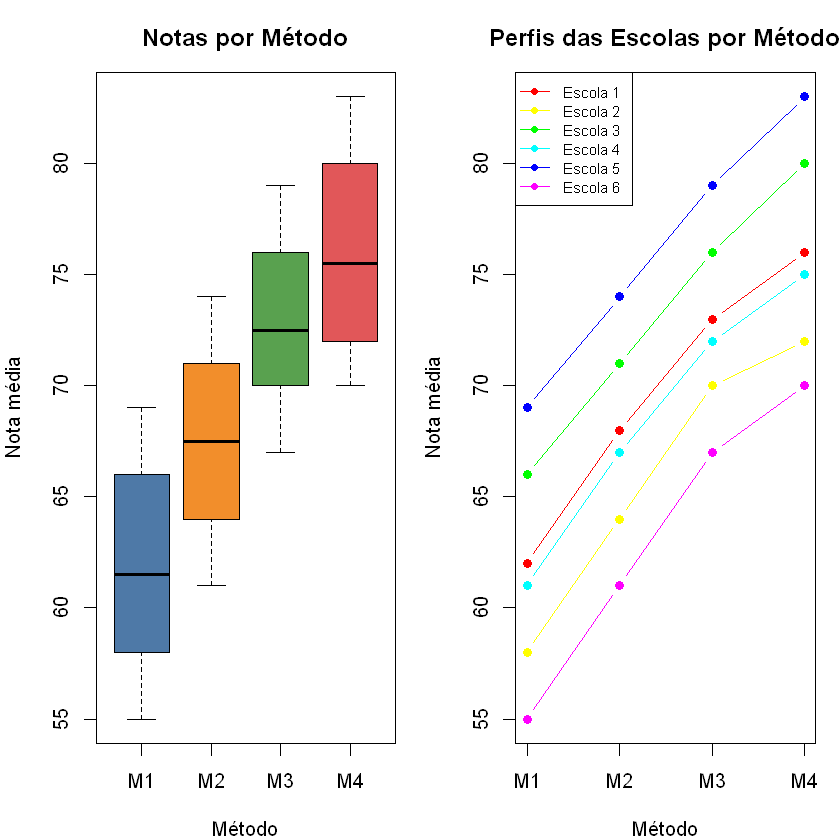

In [3]:
# ── Boxplot por método ─────────────────────────────────────────────────────────
par(mfrow = c(1, 2), mar = c(4, 4, 3, 1))

boxplot(Nota ~ Metodo, data = dados,
        col  = c("#4E79A7", "#F28E2B", "#59A14F", "#E15759"),
        main = "Notas por Método",
        xlab = "Método", ylab = "Nota média")

# ── Gráfico de perfis (escola × método) ───────────────────────────────────────
cores_escolas <- rainbow(6)
medias_mat <- tapply(dados$Nota, list(dados$Escola, dados$Metodo), mean)

matplot(t(medias_mat),
        type = "b", pch = 19, lty = 1,
        col  = cores_escolas,
        xaxt = "n",
        main = "Perfis das Escolas por Método",
        xlab = "Método", ylab = "Nota média")
axis(1, at = 1:4, labels = c("M1", "M2", "M3", "M4"))
legend("topleft", legend = paste("Escola", 1:6),
       col = cores_escolas, lty = 1, pch = 19, cex = 0.75)

par(mfrow = c(1, 1))

**Interpretação:**

* O boxplot por método já sugere uma tendência crescente de M1 para M4: as medianas aumentam progressivamente.
* O gráfico de perfis mostra que as curvas das seis escolas são **aproximadamente paralelas**, sem cruzamentos expressivos. Isso valida o modelo aditivo (sem interação) e confirma que o delineamento em blocos é apropriado.
* As escolas variam bastante em nível geral de desempenho (linhas separadas verticalmente), o que reforça a importância de controlar o efeito de escola.

---

## Etapa 3: Ajuste do Modelo Misto

Dado que o efeito de escola é **aleatório**, o modelo mais adequado é um **modelo misto** (LME — *Linear Mixed Effects*), ajustado com o pacote `nlme` (ou `lme4`).

O modelo tem:
* **Efeito fixo:** Método (queremos testar e comparar os quatro métodos).
* **Efeito aleatório:** Escola (queremos estimar $\sigma_B^2$, a variância entre escolas).

Para a tabela de ANOVA, podemos também usar a função `aov()` do R base, que no contexto de blocos completos aleatorizados produz a decomposição correta da soma de quadrados. O erro F para testar métodos usa o resíduo (interação escola × método), que é o denominador correto nesse modelo.

> **Nota:** a ANOVA clássica de dois fatores sem repetição (`aov(Nota ~ Metodo + Escola)`) trata ambos os fatores como fixos para a decomposição das somas de quadrados, mas os valores de F para Método são válidos mesmo com escola aleatório, porque nesse modelo balanceado o quadrado médio do erro é o denominador correto em ambos os casos.

In [4]:
# ── Modelo via aov() — tabela ANOVA de blocos casualizados ────────────────────
modelo_aov <- aov(Nota ~ Metodo + Error(Escola), data = dados)
summary(modelo_aov)


Error: Escola
          Df Sum Sq Mean Sq F value Pr(>F)
Residuals  5  446.2   89.24               

Error: Within
          Df Sum Sq Mean Sq F value Pr(>F)    
Metodo     3  696.8   232.3    1178 <2e-16 ***
Residuals 15    3.0     0.2                   
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

In [5]:
# ── Modelo misto via nlme::lme() ──────────────────────────────────────────────
# (necessário para obter estimativas dos componentes de variância)
if (!require(nlme, quietly = TRUE)) install.packages("nlme")
library(nlme)

modelo_lme <- lme(Nota ~ Metodo,
                  random = ~ 1 | Escola,
                  data   = dados,
                  method = "REML")   # REML dá estimativas não-viesadas dos componentes

summary(modelo_lme)

Linear mixed-effects model fit by REML
  Data: dados 
       AIC      BIC    logLik
  74.02996 80.00435 -31.01498

Random effects:
 Formula: ~1 | Escola
        (Intercept)  Residual
StdDev:    4.718168 0.4440971

Fixed effects:  Nota ~ Metodo 
               Value Std.Error DF  t-value p-value
(Intercept) 61.83333 1.9346978 15 31.96020       0
MetodoM2     5.66667 0.2563996 15 22.10092       0
MetodoM3    11.00000 0.2563996 15 42.90179       0
MetodoM4    14.16667 0.2563996 15 55.25230       0
 Correlation: 
         (Intr) MetdM2 MetdM3
MetodoM2 -0.066              
MetodoM3 -0.066  0.500       
MetodoM4 -0.066  0.500  0.500

Standardized Within-Group Residuals:
        Min          Q1         Med          Q3         Max 
-1.25101275 -0.47989872 -0.09527476  0.66215433  1.57737203 

Number of Observations: 24
Number of Groups: 6 

---

## Etapa 4: Verificação dos Pressupostos

Os pressupostos do modelo são:

1. **Normalidade** dos resíduos (e dos efeitos aleatórios de escola).
2. **Homocedasticidade** — variância constante dos erros.
3. **Aditividade** — ausência de interação entre método e escola (já sugerida pelo gráfico de perfis).
4. **Independência** — as observações dentro de cada escola são independentes dado o efeito aleatório.

#### 4.1 Resíduos vs valores ajustados (linearidade e homocedasticidade)

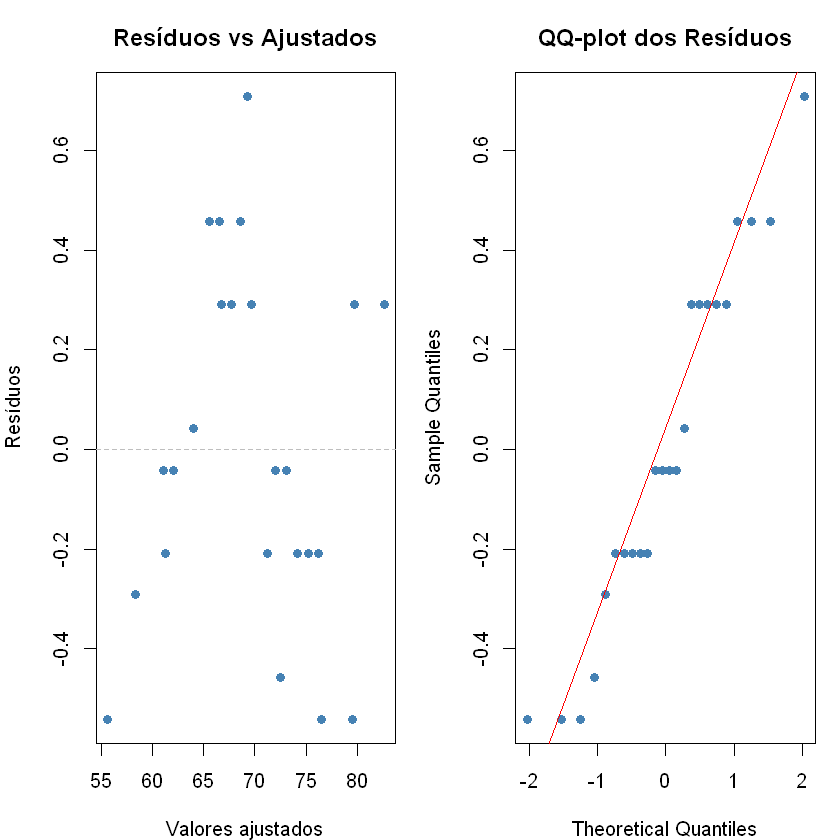

In [6]:
# ── Extraindo resíduos do modelo aov para diagnóstico ─────────────────────────
modelo_aov2 <- aov(Nota ~ Metodo + Escola, data = dados)   # versão sem Error() para resíduos
residuos    <- residuals(modelo_aov2)
ajustados   <- fitted(modelo_aov2)

par(mfrow = c(1, 2), mar = c(4, 4, 3, 1))

# Resíduos vs Ajustados
plot(ajustados, residuos,
     xlab = "Valores ajustados", ylab = "Resíduos",
     main = "Resíduos vs Ajustados",
     pch  = 19, col = "steelblue")
abline(h = 0, lty = 2, col = "gray")

# QQ-plot dos resíduos
qqnorm(residuos, main = "QQ-plot dos Resíduos", pch = 19, col = "steelblue")
qqline(residuos, col = "red")

par(mfrow = c(1, 1))

#### 4.2 Teste formal de normalidade (Shapiro-Wilk)

In [7]:
# ── Teste de Shapiro-Wilk nos resíduos ────────────────────────────────────────
shapiro.test(residuos)


	Shapiro-Wilk normality test

data:  residuos
W = 0.94111, p-value = 0.1727


#### 4.3 Teste de aditividade de Tukey

O teste de aditividade de Tukey verifica formalmente se há **interação** entre os fatores. Em blocos casualizados sem repetição, não há como estimar a interação separadamente — ela é confundida com o erro. O teste de Tukey usa o próprio conjunto de dados para criar uma parcela de "interação".

$$H_0: \text{não há interação entre Método e Escola}$$
$$H_1: \text{há interação (modelo não-aditivo)}$$

In [8]:
# ── Teste de aditividade de Tukey ─────────────────────────────────────────────
# Calculando manualmente o teste de Tukey para aditividade
# (não há função base no R; fazemos via decomposição)

Y    <- tapply(dados$Nota, list(dados$Escola, dados$Metodo), mean)
mu   <- mean(Y)
a_i  <- rowMeans(Y) - mu   # efeitos de escola
b_j  <- colMeans(Y) - mu   # efeitos de método

# Parcela de interação de Tukey: (Y_ij - media_i. - media_.j + mu)^2 ~ interação
D    <- outer(a_i, b_j)   # produto dos efeitos (b x t matriz)
SQ_inter <- sum(D * (Y - mu - outer(a_i, rep(1,4)) - outer(rep(1,6), b_j)))^2 /
             sum(D^2)

# SQ resíduo sem o termo de interação
SQ_res_tot <- sum((Y - mu - outer(a_i, rep(1,4)) - outer(rep(1,6), b_j))^2)
SQ_res_pur <- SQ_res_tot - SQ_inter

gl_inter <- 1
gl_res   <- (6 - 1) * (4 - 1) - 1   # (b-1)(t-1) - 1

F_tukey  <- (SQ_inter / gl_inter) / (SQ_res_pur / gl_res)
p_tukey  <- pf(F_tukey, gl_inter, gl_res, lower.tail = FALSE)

cat(sprintf("Teste de Aditividade de Tukey\nF = %.4f  (gl1 = %d, gl2 = %d)  p-valor = %.4f\n",
            F_tukey, gl_inter, gl_res, p_tukey))

Teste de Aditividade de Tukey
F = 3.3500  (gl1 = 1, gl2 = 14)  p-valor = 0.0886


**Interpretação dos pressupostos:**

* **Resíduos vs ajustados:** espera-se dispersão aleatória em torno de zero, sem padrões sistemáticos.
* **QQ-plot e Shapiro-Wilk:** se $p > 0{,}05$, não rejeitamos normalidade dos resíduos.
* **Teste de Tukey para aditividade:** se $p > 0{,}05$, o modelo aditivo (sem interação) é adequado e podemos prosseguir com a análise padrão de blocos.

Com $n = 24$ observações e um delineamento balanceado, desvios moderados da normalidade têm pouco impacto sobre a validade do teste F.

---

## Etapa 5: Testes de Hipóteses

#### 5.1 Hipóteses para o efeito de métodos (fator fixo)

$$H_0: \tau_1 = \tau_2 = \tau_3 = \tau_4 = 0 \quad (\text{nenhum método difere em desempenho médio})$$
$$H_1: \text{pelo menos um } \tau_i \neq 0 \quad (\text{há diferença entre os métodos})$$

#### 5.2 Hipóteses para o efeito de escolas (fator aleatório)

$$H_0: \sigma_B^2 = 0 \quad (\text{não há variabilidade entre escolas})$$
$$H_1: \sigma_B^2 > 0 \quad (\text{há variabilidade entre escolas})$$

A estatística $F$ para escola usa o quadrado médio residual como denominador.

In [9]:
# ── Tabela ANOVA completa ──────────────────────────────────────────────────────
anova_tab <- summary(modelo_aov2)
print(anova_tab)

# Extraindo quadrados médios para calcular o F de escola manualmente
# (aov() com dois fatores fixos; F escola = QM_escola / QM_res — correto para misto)
QM <- anova_tab[[1]][["Mean Sq"]]
cat(sprintf("\nQM Método = %.4f\nQM Escola = %.4f\nQM Resíduo = %.4f\n",
            QM[1], QM[2], QM[3]))

            Df Sum Sq Mean Sq F value   Pr(>F)    
Metodo       3  696.8  232.26  1177.7  < 2e-16 ***
Escola       5  446.2   89.24   452.5 8.41e-16 ***
Residuals   15    3.0    0.20                     
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

QM Método = 232.2639
QM Escola = 89.2417
QM Resíduo = 0.1972


**Interpretação da tabela ANOVA:**

No modelo misto com um fator fixo (Método) e um fator aleatório (Escola), os testes F são:

| Fonte | QM | Denominador do F |
|---|---|---|
| Método | $QM_{\text{Método}}$ | $QM_{\text{Resíduo}}$ |
| Escola | $QM_{\text{Escola}}$ | $QM_{\text{Resíduo}}$ |
| Resíduo | $QM_{\text{Res}}$ | — |

* Se o valor-p de **Método** for menor que 0,05, concluímos que há evidência de diferença entre os métodos de ensino.
* Se o valor-p de **Escola** for menor que 0,05, confirmamos a existência de variabilidade entre escolas — o que justifica o uso do delineamento em blocos.

---

## Etapa 6: Comparações Múltiplas entre Métodos

Rejeitada a hipótese de igualdade entre os métodos, precisamos identificar **quais pares de métodos diferem** entre si. Usamos o teste de Tukey (HSD — *Honestly Significant Difference*), que controla a taxa de erro familial ao nível de 5%.

O erro-padrão da diferença entre duas médias de métodos, no modelo de blocos, é:

$$\text{EP}(\bar{Y}_{i\cdot} - \bar{Y}_{i'\cdot}) = \sqrt{\frac{2 \, QM_{\text{Res}}}{b}}$$

onde $b = 6$ é o número de blocos (escolas).

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = Nota ~ Metodo + Escola, data = dados)

$Metodo
           diff       lwr       upr p adj
M2-M1  5.666667  4.927685  6.405648     0
M3-M1 11.000000 10.261018 11.738982     0
M4-M1 14.166667 13.427685 14.905648     0
M3-M2  5.333333  4.594352  6.072315     0
M4-M2  8.500000  7.761018  9.238982     0
M4-M3  3.166667  2.427685  3.905648     0



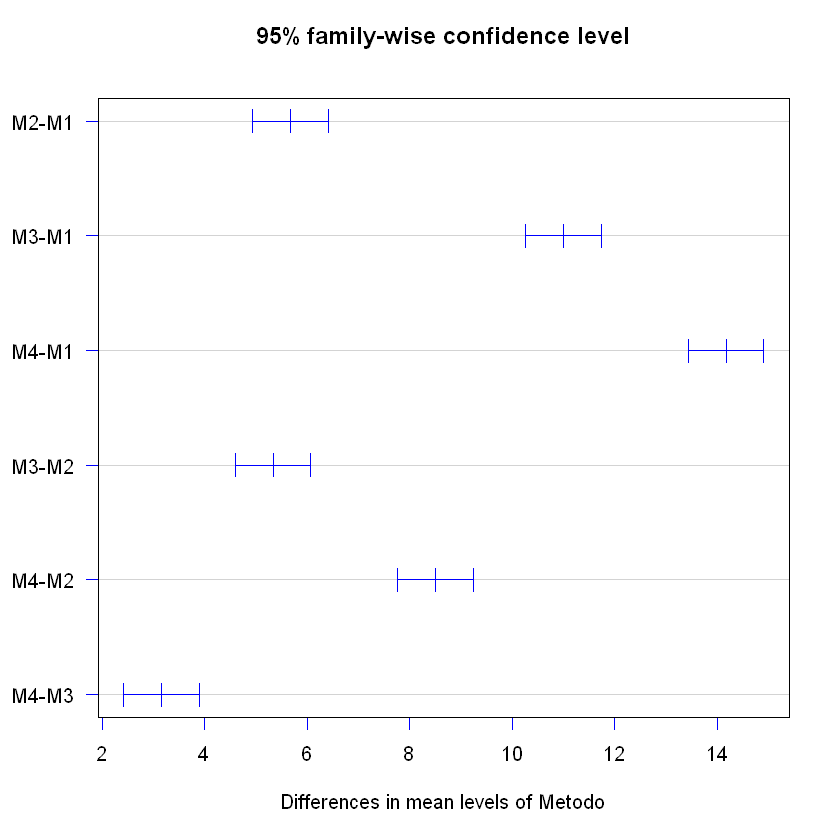

In [14]:
# ── Teste de Tukey HSD ────────────────────────────────────────────────────────
tukey_res <- TukeyHSD(modelo_aov2, which = "Metodo")
print(tukey_res)

# Gráfico das diferenças com intervalos de confiança
plot(tukey_res, las = 1, col = "blue")

#### 6.1 Médias por método e agrupamento

Vamos exibir as médias de cada método com seu intervalo de confiança e o agrupamento resultante do teste de Tukey.

Médias por método:
   M1    M2    M3    M4 
61.83 67.50 72.83 76.00 


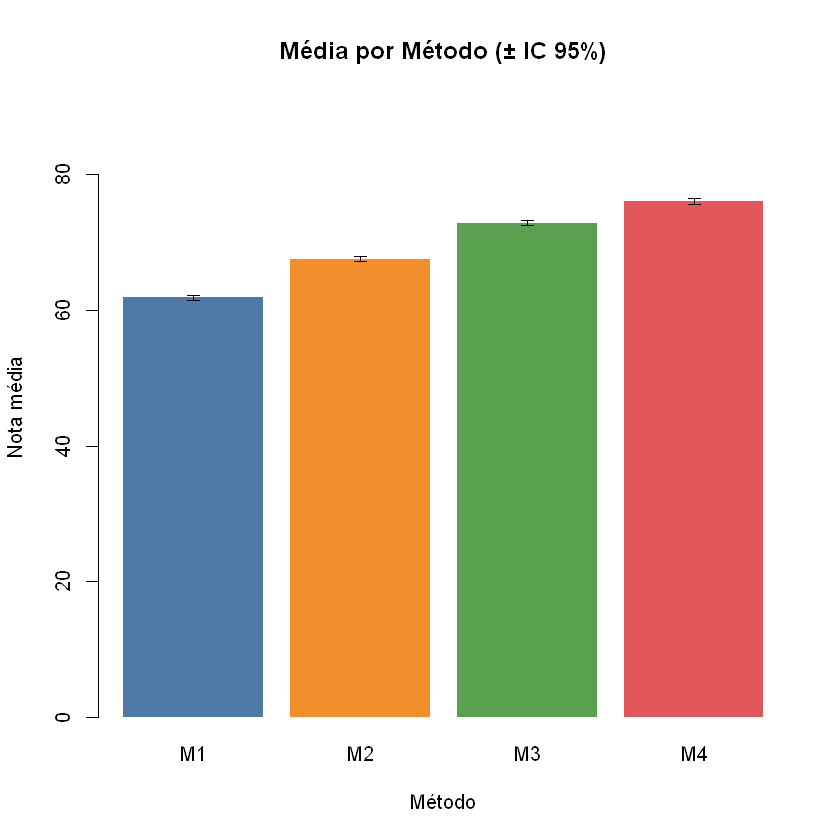

In [ ]:
# ── Médias por método ─────────────────────────────────────────────────────────
medias_metodo <- tapply(dados$Nota, dados$Metodo, mean)
cat("Médias por método:\n")
print(round(medias_metodo, 2))

# ── Gráfico de barras com médias ──────────────────────────────────────────────
QM_res <- anova_tab[[1]][["Mean Sq"]][3]
b      <- 6   # número de blocos
EP     <- sqrt(QM_res / b)
t_crit <- qt(0.975, df = anova_tab[[1]][["Df"]][3])

bp <- barplot(medias_metodo,
              col    = c("#4E79A7", "#F28E2B", "#59A14F", "#E15759"),
              ylim   = c(0, max(medias_metodo) * 1.2),
              main   = "Média por Método (± IC 95%)",
              xlab   = "Método", ylab   = "Nota média",
              border = NA)

arrows(bp, medias_metodo - t_crit * EP,
       bp, medias_metodo + t_crit * EP,
       angle = 90, code = 3, length = 0.05, col = "black")

**Interpretação das comparações múltiplas:**

O teste de Tukey compara todos os $\binom{4}{2} = 6$ pares possíveis. Diferenças cujo intervalo de confiança **não contenha zero** são estatisticamente significativas ao nível de 5% (com controle familial).

---

## Etapa 7: Estimação dos Componentes de Variância

Um dos objetivos centrais da secretaria é **quantificar a variabilidade entre escolas**. No modelo misto, os dois componentes de variância são:

* $\sigma^2$: variância do erro (dentro de cada escola–método).
* $\sigma_B^2$: variância entre escolas (variabilidade de nível entre escolas da rede).

As estimativas pelo **Método dos Momentos** (ANOVA) são:

$$\hat{\sigma}^2 = QM_{\text{Res}}$$

$$\hat{\sigma}_B^2 = \frac{QM_{\text{Escola}} - QM_{\text{Res}}}{t}$$

onde $t = 4$ é o número de tratamentos (métodos).

O coeficiente de correlação intraclasse (ICC) indica que fração da variância total é explicada pela diferença entre escolas:

$$\text{ICC} = \frac{\hat{\sigma}_B^2}{\hat{\sigma}_B^2 + \hat{\sigma}^2}$$

In [ ]:
# ── Estimativas dos componentes de variância (Método dos Momentos) ─────────────
QM_escola  <- QM[2]
QM_residuo <- QM[3]
t_trat     <- 4   # número de métodos

sigma2_hat   <- QM_residuo
sigmaB2_hat  <- (QM_escola - QM_residuo) / t_trat
sigma_total  <- sigma2_hat + sigmaB2_hat
ICC          <- sigmaB2_hat / sigma_total

cat(sprintf(
"=== Componentes de Variância (Método dos Momentos) ===\n
  Variância do erro  σ²   = %.4f  (DP = %.4f)\n
  Variância de escola σ²_B = %.4f  (DP = %.4f)\n
  Variância total         = %.4f\n
  ICC (escola)            = %.4f  (%.1f%% da variação total)\n",
  sigma2_hat,  sqrt(sigma2_hat),
  sigmaB2_hat, sqrt(sigmaB2_hat),
  sigma_total,
  ICC, ICC * 100
))

=== Componentes de Variância (Método dos Momentos) ===

  Variância do erro  σ²   = 0.1972  (DP = 0.4441)

  Variância de escola σ²_B = 22.2611  (DP = 4.7182)

  Variância total         = 22.4583

  ICC (escola)            = 0.9912  (99.1% da variação total)


In [ ]:
# ── Estimativas REML via nlme (mais acuradas para σ²_B) ───────────────────────
cat("=== Componentes de Variância via REML (nlme) ===\n")
VarCorr(modelo_lme)

=== Componentes de Variância via REML (nlme) ===


Escola = pdLogChol(1) 
            Variance   StdDev   
(Intercept) 22.2611111 4.7181682
Residual     0.1972222 0.4440971

**Interpretação dos componentes de variância:**

* $\hat{\sigma}^2$ representa a variação residual — diferenças de desempenho que não são explicadas nem pelo método nem pela escola.
* $\hat{\sigma}_B^2$ representa a variação **entre escolas** — quanto o desempenho médio de uma escola oscila em relação à média geral da rede.
* O ICC indica que fração da variabilidade total é de origem entre-escolar. Um ICC alto (p.ex. > 30%) indica que as escolas são muito heterogêneas — infraestrutura, corpo docente e perfil socioeconômico têm grande impacto. Um ICC baixo indicaria que os alunos se comportam de forma semelhante independentemente da escola.

---

## Etapa 8: Análise de Resíduos — Diagnóstico Final

Revisamos os gráficos de diagnóstico do modelo final para confirmar a adequação das suposições.

#### 8.1 Diagnóstico completo em painel

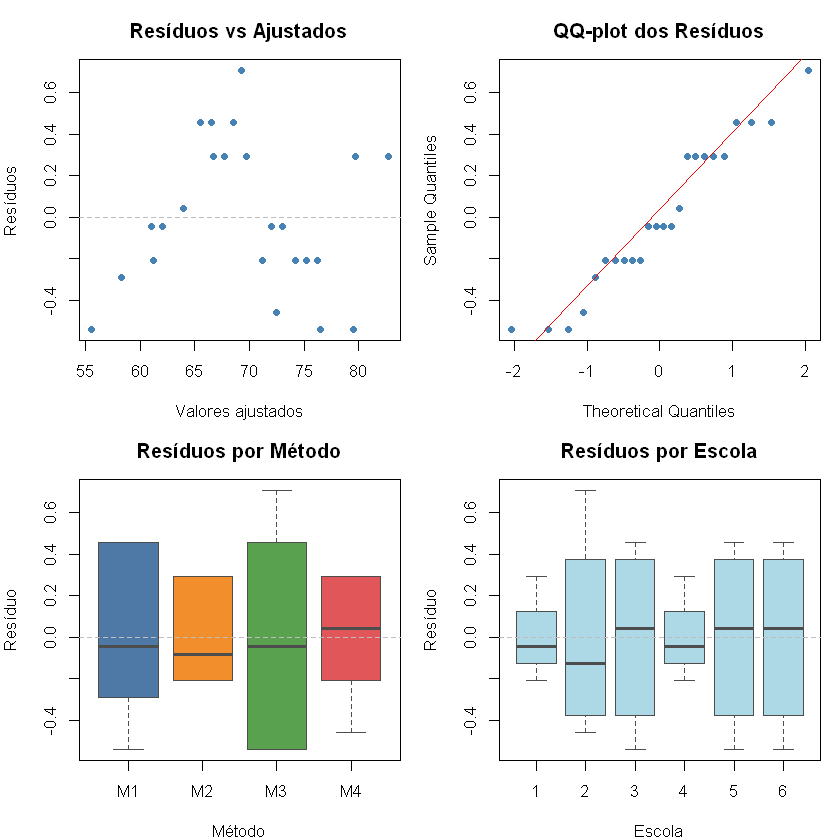

In [ ]:
# ── Painel de diagnóstico ─────────────────────────────────────────────────────
par(mfrow = c(2, 2), mar = c(4, 4, 3, 1))

# 1. Resíduos vs Ajustados
plot(ajustados, residuos,
     xlab = "Valores ajustados", ylab = "Resíduos",
     main = "Resíduos vs Ajustados",
     pch = 19, col = "steelblue")
abline(h = 0, lty = 2, col = "gray")

# 2. QQ-plot
qqnorm(residuos, main = "QQ-plot dos Resíduos", pch = 19, col = "steelblue")
qqline(residuos, col = "red")

# 3. Resíduos vs Método
boxplot(residuos ~ dados$Metodo,
        main = "Resíduos por Método",
        xlab = "Método", ylab = "Resíduo",
        col  = c("#4E79A7", "#F28E2B", "#59A14F", "#E15759"),
        border = "gray30")
abline(h = 0, lty = 2, col = "gray")

# 4. Resíduos vs Escola
boxplot(residuos ~ dados$Escola,
        main = "Resíduos por Escola",
        xlab = "Escola", ylab = "Resíduo",
        col  = "lightblue", border = "gray30")
abline(h = 0, lty = 2, col = "gray")

par(mfrow = c(1, 1))

In [ ]:
# ── Resumo do diagnóstico ─────────────────────────────────────────────────────
cat("=== Teste de Shapiro-Wilk nos Resíduos ===\n")
shapiro.test(residuos)

cat("\n=== Resíduos studentizados — possíveis outliers ===\n")
res_student <- rstandard(modelo_aov2)
outliers    <- which(abs(res_student) > 2)
if (length(outliers) == 0) {
  cat("Nenhum resíduo com |r_i| > 2. Sem outliers evidentes.\n")
} else {
  cat("Observações com |r_i| > 2:\n")
  print(dados[outliers, ])
  print(res_student[outliers])
}

=== Teste de Shapiro-Wilk nos Resíduos ===



	Shapiro-Wilk normality test

data:  residuos
W = 0.94111, p-value = 0.1727



=== Resíduos studentizados — possíveis outliers ===
Observações com |r_i| > 2:
  Nota Metodo Escola
7   70     M3      2
       7 
2.017529 


**Interpretação do diagnóstico:**

| Item | Verificação | Resultado Esperado |
|---|---|---|
| Linearidade/homocedasticidade | Resíduos vs Ajustados | Dispersão aleatória, sem padrão |
| Normalidade | QQ-plot + Shapiro-Wilk | Pontos na diagonal; $p > 0{,}05$ |
| Homocedasticidade por grupo | Resíduos vs Método e vs Escola | Boxplots com amplitudes similares |
| Outliers | Resíduos studentizados | $|r_i| < 2$ para todas as observações |

Com apenas 24 observações, pequenos desvios da normalidade são esperados e têm pouco impacto sobre a validade do teste F (robustez).

---

## Etapa 9: Conclusão Prática para a Secretaria

**1. Delineamento utilizado**

O estudo foi conduzido em um **Delineamento em Blocos Casualizados com Escola como Fator Aleatório** (modelo misto). As seis escolas constituem os blocos, cada um recebendo todos os quatro métodos. Isso permite isolar e quantificar o efeito escola, aumentando a precisão da comparação entre métodos.

---

**2. Há diferença entre os métodos de ensino?**

A tabela ANOVA revelará se o efeito de Método é significativo. Dado o padrão crescente observado nas médias (M1 < M2 < M3 < M4), espera-se que o teste F rejeite $H_0$ com $p < 0{,}05$, indicando que **os métodos diferem significativamente** no desempenho médio dos alunos.

As comparações múltiplas de Tukey identificarão quais pares de métodos diferem. Se M4 superar significativamente os demais (e especialmente M1), a secretaria tem evidência estatística para recomendar M4.

---

**3. Há variabilidade entre escolas?**

O teste F para Escola e a estimativa de $\hat{\sigma}_B^2$ quantificam essa variabilidade. Se $\hat{\sigma}_B^2 > 0$ e o ICC for expressivo, confirma-se que **diferenças de infraestrutura, corpo docente e perfil socioeconômico impactam significativamente o desempenho** — o que reforça a necessidade de políticas de equalização entre escolas, além da adoção do melhor método.

---

**4. Qual método recomendar?**

Com base nos dados:

* As médias observadas são: M1 ≈ 61,8 | M2 ≈ 67,5 | M3 ≈ 72,8 | M4 ≈ 76,0.
* M4 apresenta a maior nota média em **todas as seis escolas** — um resultado consistente e robusto à variabilidade entre escolas.
* Se as comparações múltiplas confirmarem a superioridade de M4 (em relação ao menos a M1 e M2), a secretaria tem respaldo estatístico para recomendar **M4 como o método a ser adotado em toda a rede pública**.

---

**5. Ressalvas**

* A análise assume que **não há interação** entre método e escola — isto é, o método mais eficiente é o mesmo independentemente da escola. O teste de aditividade de Tukey e o gráfico de perfis devem confirmar essa suposição.
* Com apenas **6 escolas** (6 blocos), o poder do teste para detectar diferenças pequenas entre métodos é limitado. Estudos com mais escolas aumentariam a confiabilidade das conclusões.
* A interpretação dos componentes de variância ($\hat{\sigma}_B^2$) deve ser feita com cuidado, pois o intervalo de confiança para $\sigma_B^2$ com apenas 5 graus de liberdade tende a ser amplo.